In [1]:
# Practice  task 
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans 


In [2]:
iris = load_iris()
x = iris.data
y = iris.target

<Axes: >

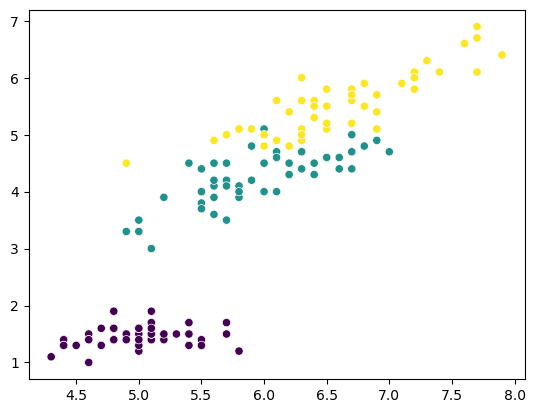

In [3]:
# vislualize 
sns.scatterplot(x = x[:,0], y = x [:,2], c=y)

In [4]:
# sacling the data
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
x_scaled = scalar.fit_transform(x)

In [5]:
# Dimentionality reeduction using pca
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
pca_data=pca.fit_transform(x_scaled)

In [6]:
#elbow mwethod
wcss =  []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)
    

C:\Users\dhruv\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dhruv\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dhruv\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dhruv\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

<Axes: >

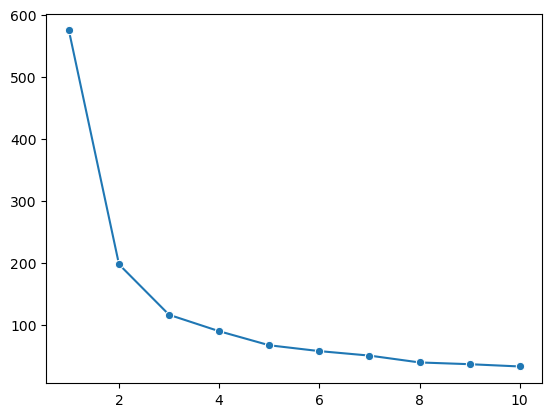

In [7]:
sns.lineplot(x = range(1,11), y = wcss , marker='o')

In [8]:
from kneed import KneeLocator
knee=KneeLocator(range(1,11),wcss , curve="convex",direction="decreasing")
print("optimal k -->",knee.elbow)

optimal k --> 3


C:\Users\dhruv\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: >

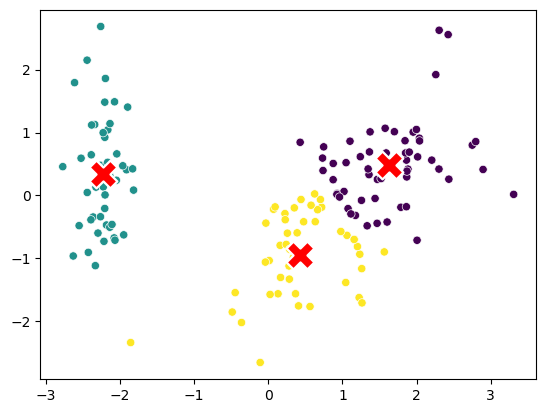

In [9]:
# kmeans
kmeans = KMeans(n_clusters=3,random_state=10
               )
labels = kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,1],marker = "X",c="red",s=400)